In [1]:
import sys
import types
m = types.ModuleType('pyjks')
sys.modules['pyjks'] = m

import os
from dotenv import load_dotenv
import hopsworks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv()
API_KEY_HS = os.getenv('API_KEY_HS')

project = hopsworks.login(
    api_key_value=API_KEY_HS,
    project="Pearls_AQI_Predictor12",
    host="eu-west.cloud.hopsworks.ai"
)
fs = project.get_feature_store()
fg = fs.get_feature_group("karachi_aqi_openmeteo", version=1)

df = fg.read(online=True)
print(f"Loaded {len(df)} rows")
df.head()

2026-05-28 22:27:41,547 WARNING: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'

2026-05-28 22:27:41,557 WARNING: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'

2026-05-28 22:27:41,557 WARNING: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'

2026-05-28 22:27:41,847 WARNING: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'

2026-05-28 22:27:41,908 WARNING: In C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: 'parseString' deprecated - use 'parse_string'
2026-05-28 22:27:41,908 WARNING: In C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: 'resetCache' deprecated - use 'reset_cache'
2026-05-28 22:27:42,387 INFO: Initiali

,event_timestamp,pm2_5,pm10,co,no2,so2,o3,european_aqi,wind_speed,wind_direction,temperature,humidity,precipitation,pressure,location,aqi_is_poor,pm25_exceeds_who
0,2026-05-22 14:00:00,45.6,143.9,230.0,3.8,6.2,103.0,82.0,14.1,227.0,32.9,60.0,0.0,1006.1,Karachi_Lyari,1,1
1,2013-01-01 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,265.0,17.9,57.0,0.0,1012.7,Karachi_Lyari,0,0
2,2013-01-06 11:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.1,99.0,20.5,40.0,0.0,1017.1,Karachi_Lyari,0,0
3,2013-01-06 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.2,231.0,19.7,62.0,0.0,1015.1,Karachi_Lyari,0,0
4,2013-01-17 06:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.6,30.0,16.2,68.0,0.0,1013.3,Karachi_Lyari,0,0


Rows with all pollution = 0: 84053/117414 (71.6%)

Data quality by year:
      total_rows  zero_pm25   avg_pm25  zero_pct
year                                            
2013        8760       8760   0.000000     100.0
2014        8760       8760   0.000000     100.0
2015        8760       8760   0.000000     100.0
2016        8784       8784   0.000000     100.0
2017        8760       8760   0.000000     100.0
2018        8760       8760   0.000000     100.0
2019        8760       8760   0.000000     100.0
2020        8784       8784   0.000000     100.0
2021        8760       8760   0.000000     100.0
2022        8760       5165  16.923756      59.0
2023        8760          0  32.670537       0.0
2024        8784          0  26.770128       0.0
2025        8760          0  29.183756       0.0
2026        3462          0  28.942577       0.0


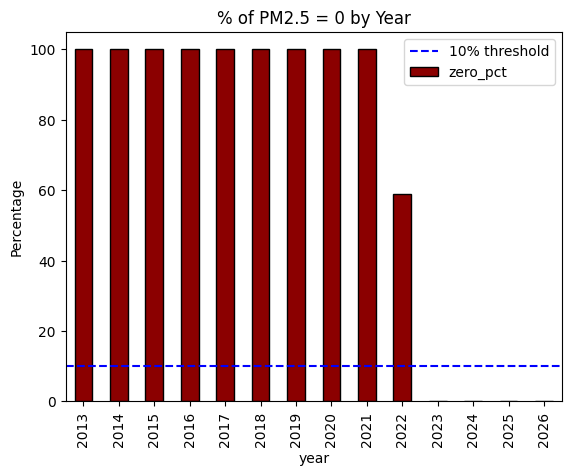

In [2]:
zero_pollution = (df['pm2_5'] == 0) & (df['pm10'] == 0) & (df['co'] == 0)
print(f"Rows with all pollution = 0: {zero_pollution.sum()}/{len(df)} ({zero_pollution.mean()*100:.1f}%)")

df['year'] = df['event_timestamp'].dt.year
yearly_quality = df.groupby('year').agg(
    total_rows=('pm2_5', 'count'),
    zero_pm25=('pm2_5', lambda x: (x == 0).sum()),
    avg_pm25=('pm2_5', 'mean')
)
yearly_quality['zero_pct'] = (yearly_quality['zero_pm25'] / yearly_quality['total_rows'] * 100).round(1)
print("\nData quality by year:")
print(yearly_quality)

import matplotlib.pyplot as plt
yearly_quality['zero_pct'].plot(kind='bar', color='darkred', edgecolor='black')
plt.title('% of PM2.5 = 0 by Year')
plt.ylabel('Percentage')
plt.axhline(y=10, color='blue', linestyle='--', label='10% threshold')
plt.legend()
plt.show()

In [3]:
df = fg.read(online=True)
df['year'] = df['event_timestamp'].dt.year
df = df[df['year'] >= 2023].copy()
print(f"Clean data: {len(df)} rows | Range: {df['event_timestamp'].min()} → {df['event_timestamp'].max()}")

Clean data: 29766 rows | Range: 2023-01-01 00:00:00 → 2026-05-28 19:00:00


In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nDate range:", df['event_timestamp'].min(), "→", df['event_timestamp'].max())

Shape: (29766, 18)

Columns: ['event_timestamp', 'pm2_5', 'pm10', 'co', 'no2', 'so2', 'o3', 'european_aqi', 'wind_speed', 'wind_direction', 'temperature', 'humidity', 'precipitation', 'pressure', 'location', 'aqi_is_poor', 'pm25_exceeds_who', 'year']

Missing values:
 event_timestamp     0
pm2_5               0
pm10                0
co                  0
no2                 0
so2                 0
o3                  0
european_aqi        0
wind_speed          0
wind_direction      0
temperature         0
humidity            0
precipitation       0
pressure            0
location            0
aqi_is_poor         0
pm25_exceeds_who    0
year                0
dtype: int64

Date range: 2023-01-01 00:00:00 → 2026-05-28 19:00:00


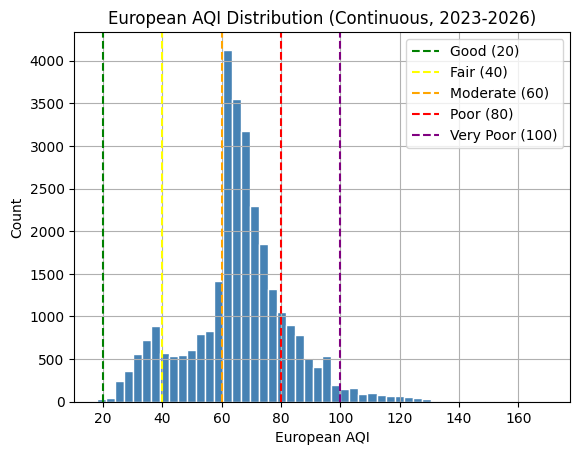

In [5]:
df['european_aqi'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('European AQI Distribution (Continuous, 2023-2026)')
plt.xlabel('European AQI')
plt.ylabel('Count')

plt.axvline(x=20, color='green', linestyle='--', label='Good (20)')
plt.axvline(x=40, color='yellow', linestyle='--', label='Fair (40)')
plt.axvline(x=60, color='orange', linestyle='--', label='Moderate (60)')
plt.axvline(x=80, color='red', linestyle='--', label='Poor (80)')
plt.axvline(x=100, color='purple', linestyle='--', label='Very Poor (100)')
plt.legend()
plt.show()

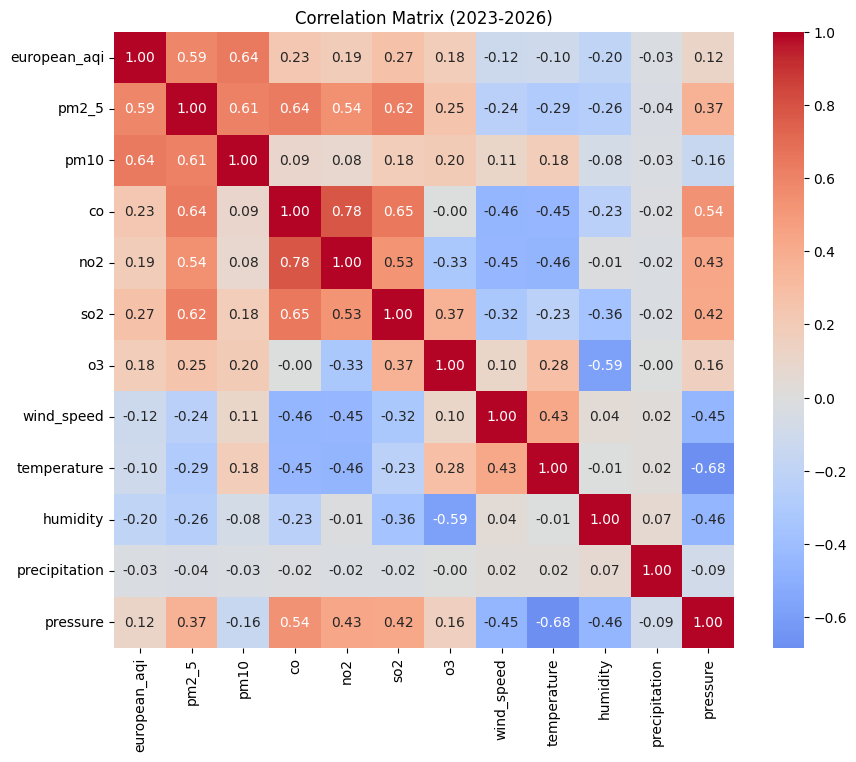

Top correlates with European AQI:
european_aqi     1.000000
pm10             0.640673
pm2_5            0.590006
so2              0.268267
co               0.234342
no2              0.193993
o3               0.182703
pressure         0.116921
precipitation   -0.031936
temperature     -0.103777
Name: european_aqi, dtype: float64


In [6]:
corr_cols = ['european_aqi', 'pm2_5', 'pm10', 'co', 'no2', 'so2', 'o3',
             'wind_speed', 'temperature', 'humidity', 'precipitation', 'pressure']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (2023-2026)')
plt.show()

print("Top correlates with European AQI:")
print(df[corr_cols].corr()['european_aqi'].sort_values(ascending=False).head(10))

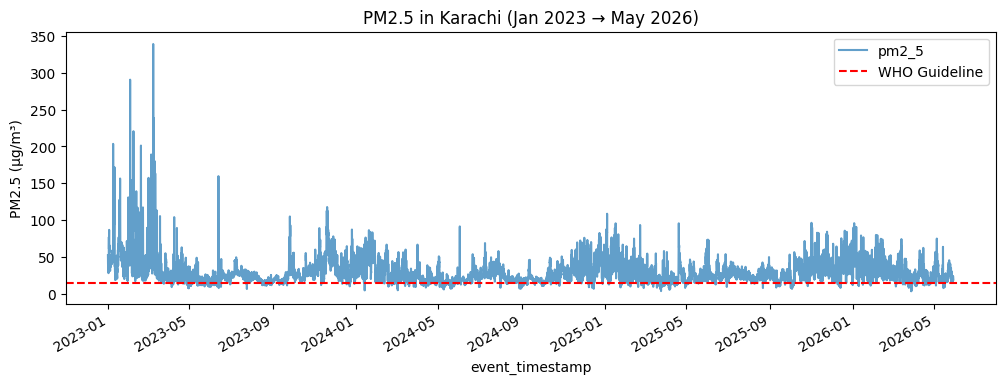

In [7]:
df.set_index('event_timestamp')['pm2_5'].plot(figsize=(12,4), alpha=0.7)
plt.title(f'PM2.5 in Karachi ({df["event_timestamp"].min().strftime("%b %Y")} → {df["event_timestamp"].max().strftime("%b %Y")})')
plt.ylabel('PM2.5 (µg/m³)')
plt.axhline(y=15, color='red', linestyle='--', label='WHO Guideline')
plt.legend()
plt.show()

In [8]:
df['aqi_change_24h'] = df['european_aqi'] - df['european_aqi'].shift(24)
change_corr = df[['wind_speed', 'precipitation', 'temperature', 'pressure', 'aqi_change_24h']].corr()
print("Weather vs AQI CHANGE (not level):")
print(change_corr['aqi_change_24h'].sort_values(ascending=False))

Weather vs AQI CHANGE (not level):
aqi_change_24h    1.000000
pressure          0.082114
precipitation    -0.011596
temperature      -0.091920
wind_speed       -0.116683
Name: aqi_change_24h, dtype: float64


In [9]:
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])

df['month'] = df['event_timestamp'].dt.month
df['hour_of_day'] = df['event_timestamp'].dt.hour
df['day_of_week'] = df['event_timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print("Added: hour_of_day, day_of_week, is_weekend")

Added: hour_of_day, day_of_week, is_weekend


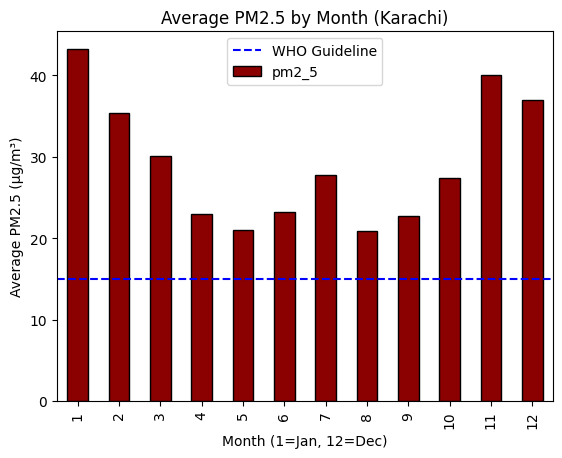

In [10]:
df['month'] = df['event_timestamp'].dt.month
monthly_pm25 = df.groupby('month')['pm2_5'].mean()
monthly_pm25.plot(kind='bar', color='darkred', edgecolor='black')
plt.title('Average PM2.5 by Month (Karachi)')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.axhline(y=15, color='blue', linestyle='--', label='WHO Guideline')
plt.legend()
plt.show()

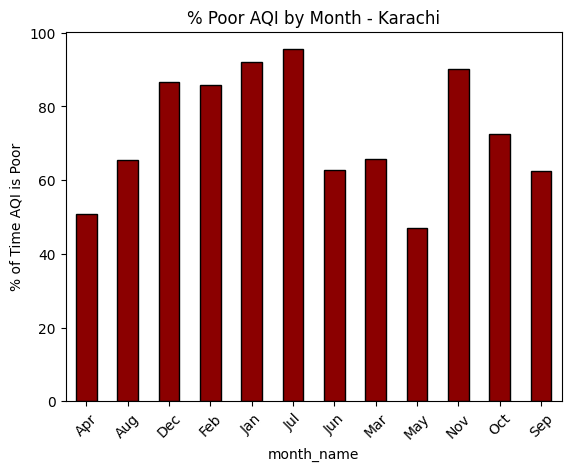

In [11]:
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
df['month_name'] = df['month'].map(month_names)

monthly_aqi = df.groupby('month_name')['aqi_is_poor'].mean() * 100
monthly_aqi.plot(kind='bar', color='darkred', edgecolor='black')
plt.title('% Poor AQI by Month - Karachi')
plt.ylabel('% of Time AQI is Poor')
plt.xticks(rotation=45)
plt.show()

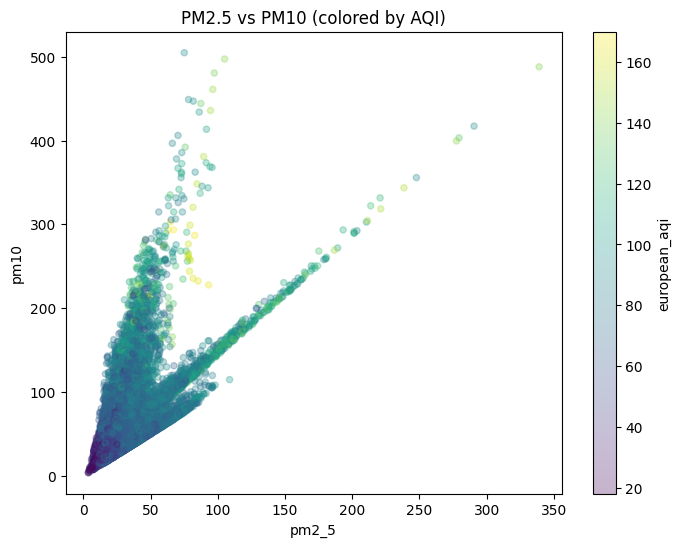

PM10-dominant events: 2430
Average AQI during PM10-dominant: 84.7


In [12]:
df.plot.scatter(x='pm2_5', y='pm10', c='european_aqi', colormap='viridis', alpha=0.3, figsize=(8,6))
plt.title('PM2.5 vs PM10 (colored by AQI)')
plt.show()

df['pm10_dominant'] = (df['pm10'] > 100) & (df['pm2_5'] < 50)
print(f"PM10-dominant events: {df['pm10_dominant'].sum()}")
print(f"Average AQI during PM10-dominant: {df[df['pm10_dominant']]['european_aqi'].mean():.1f}")

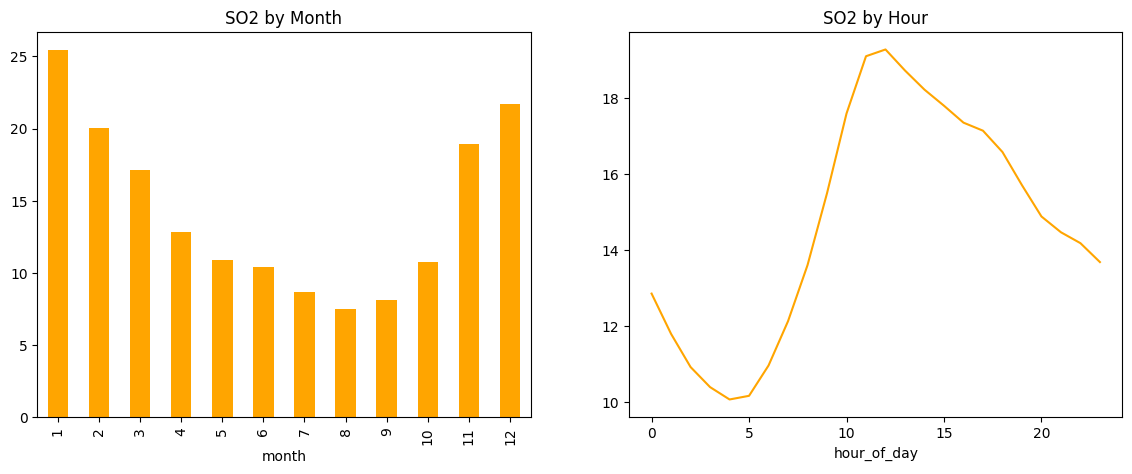

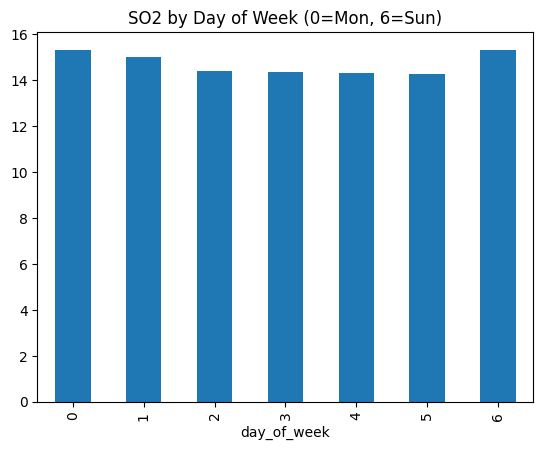

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df.groupby('month')['so2'].mean().plot(kind='bar', ax=axes[0], color='orange')
axes[0].set_title('SO2 by Month')
df.groupby('hour_of_day')['so2'].mean().plot(ax=axes[1], color='orange')
axes[1].set_title('SO2 by Hour')
plt.show()

df.groupby('day_of_week')['so2'].mean().plot(kind='bar')
plt.title('SO2 by Day of Week (0=Mon, 6=Sun)')
plt.show()

In [14]:
may = df[df['month'] == 9]
other_months = df[df['month'] != 9]

print("May vs Rest of Year:")
for col in ['pm2_5', 'pm10', 'so2', 'co', 'no2', 'o3']:
    print(f"  {col}: {may[col].mean():.0f} vs {other_months[col].mean():.0f}")

drops = {}
for col in ['pm2_5', 'pm10', 'so2', 'co', 'no2']:
    drops[col] = other_months[col].mean() - may[col].mean()
print("\nBiggest drop in May:", max(drops, key=drops.get))

May vs Rest of Year:
  pm2_5: 23 vs 30
  pm10: 66 vs 62
  so2: 8 vs 15
  co: 246 vs 507
  no2: 14 vs 21
  o3: 52 vs 76

Biggest drop in May: co


In [15]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

df['pm25_yesterday'] = df['pm2_5'].shift(24)
df['pm10_yesterday'] = df['pm10'].shift(24)
df['pm25_6h_trend'] = df['pm2_5'] - df['pm2_5'].shift(6)
df['aqi_yesterday'] = df['european_aqi'].shift(24)

df['aqi_tomorrow'] = df['european_aqi'].shift(-24)

features = [
    'pm2_5', 'pm10', 'so2', 'co', 'no2',
    'pm25_yesterday', 'pm10_yesterday', 'pm25_6h_trend', 'aqi_yesterday',
    'wind_speed', 'temperature', 'humidity', 'precipitation', 'pressure',
    'hour_of_day', 'month'
]

df_model = df.dropna(subset=features + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

X_train = train[features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[features].fillna(0)
y_test = test['aqi_tomorrow']

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

persist_mae = mean_absolute_error(y_test, test['european_aqi'])
print(f"Persistence MAE: {persist_mae:.1f}")

model = XGBRegressor(n_estimators=100, max_depth=4, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
model_mae = mean_absolute_error(y_test, preds)

print(f"Model MAE:      {model_mae:.1f}")
print(f"Improvement:    {'BETTER' if model_mae < persist_mae else 'WORSE'}")

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop 5 features:")
print(importance.head(5))

Train: 17523 | Test: 12195
Persistence MAE: 17.0
Model MAE:      12.1
Improvement:    BETTER

Top 5 features:
          feature  importance
15          month    0.116488
2             so2    0.085035
9      wind_speed    0.065293
13       pressure    0.065187
7   pm25_6h_trend    0.064151


In [16]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

df['pm25_yesterday'] = df['pm2_5'].shift(24)
df['pm10_yesterday'] = df['pm10'].shift(24)
df['pm25_6h_trend'] = df['pm2_5'] - df['pm2_5'].shift(6)
df['aqi_yesterday'] = df['european_aqi'].shift(24)

df['pm25_2d_ago'] = df['pm2_5'].shift(48)
df['pm25_3d_ago'] = df['pm2_5'].shift(72)
df['aqi_12h_ago'] = df['european_aqi'].shift(12)
df['aqi_2d_ago'] = df['european_aqi'].shift(48)
df['wind_yesterday'] = df['wind_speed'].shift(24)
df['temp_yesterday'] = df['temperature'].shift(24)

df['pressure_24h_change'] = df['pressure'] - df['pressure'].shift(24)
df['temp_24h_change'] = df['temperature'] - df['temperature'].shift(24)

df['aqi_tomorrow'] = df['european_aqi'].shift(-24)

features= [
    'pm2_5', 'pm10', 'so2', 'co', 'no2',
    'pm25_yesterday', 'pm25_2d_ago', 'pm10_yesterday',
    'pm25_6h_trend', 'aqi_yesterday', 'aqi_12h_ago',
    'wind_speed', 'wind_yesterday', 'temperature', 'temp_yesterday',
    'humidity', 'precipitation', 'pressure', 'pressure_24h_change',
    'hour_of_day', 'month'
]

df_model = df.dropna(subset=features + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

X_train = train[features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[features].fillna(0)
y_test = test['aqi_tomorrow']

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

persist_mae = mean_absolute_error(y_test, test['european_aqi'])
print(f"Persistence MAE: {persist_mae:.1f}")

model = XGBRegressor(n_estimators=100, max_depth=4, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
model_mae = mean_absolute_error(y_test, preds)

print(f"Model MAE:      {model_mae:.1f}")
print(f"Improvement:    {'BETTER' if model_mae < persist_mae else 'WORSE'}")

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop 5 features:")
print(importance.head(5))

Train: 17499 | Test: 12195
Persistence MAE: 17.0
Model MAE:      12.1
Improvement:    BETTER

Top 5 features:
           feature  importance
20           month    0.084589
2              so2    0.070875
14  temp_yesterday    0.057756
17        pressure    0.054782
11      wind_speed    0.050602


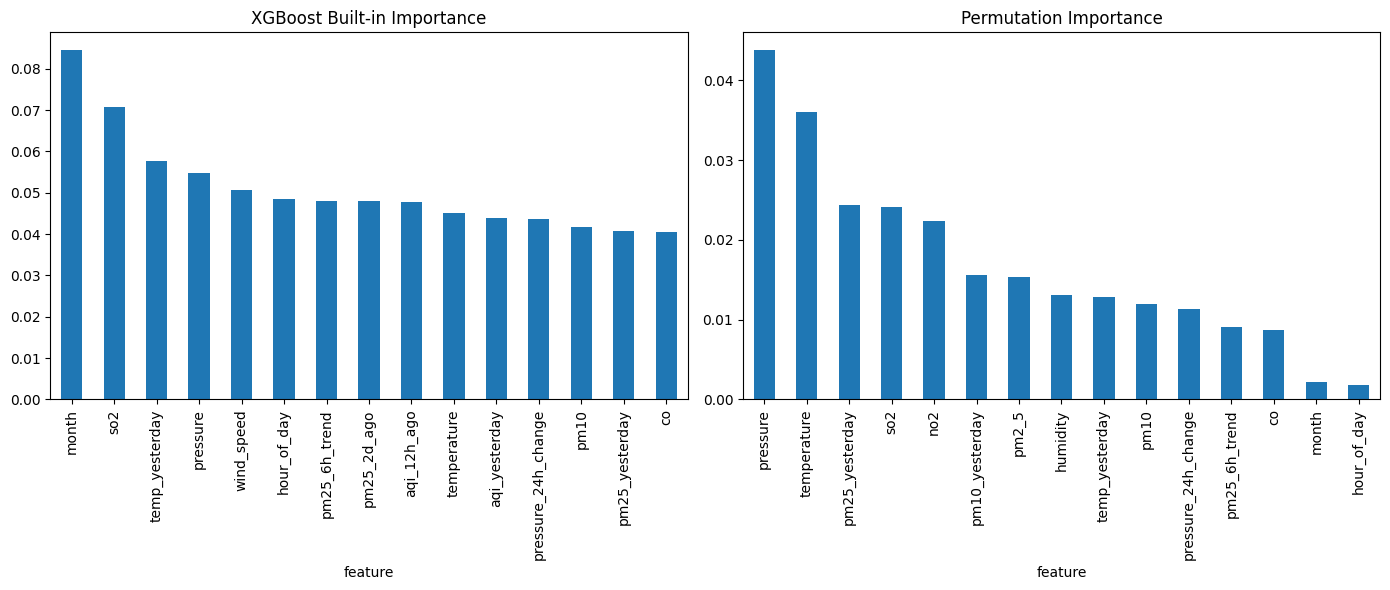

Top features by importance:
  pressure             | Importance: 0.0438
  temperature          | Importance: 0.0360
  pm25_yesterday       | Importance: 0.0244
  so2                  | Importance: 0.0241
  no2                  | Importance: 0.0224
  pm10_yesterday       | Importance: 0.0156
  pm2_5                | Importance: 0.0154
  humidity             | Importance: 0.0131
  temp_yesterday       | Importance: 0.0129
  pm10                 | Importance: 0.0120
Final features (11): ['pm2_5', 'pressure_24h_change', 'pm25_yesterday', 'no2', 'so2', 'humidity', 'pm10_yesterday', 'pressure', 'temp_yesterday', 'temperature', 'pm10']


In [17]:
from sklearn.inspection import permutation_importance

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

perm_importance = permutation_importance(model, X_test, y_test, n_repeats=3, random_state=42)
perm_df = pd.DataFrame({
    'feature': features,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
importance.head(15).plot(kind='bar', x='feature', y='importance', ax=axes[0], legend=False)
axes[0].set_title('XGBoost Built-in Importance')
perm_df.head(15).plot(kind='bar', x='feature', y='importance', ax=axes[1], legend=False)
axes[1].set_title('Permutation Importance')
plt.tight_layout()
plt.show()

perm_df = perm_df.sort_values('importance', ascending=False)
print("Top features by importance:")
for i, row in perm_df.head(10).iterrows():
    print(f"  {row['feature']:20s} | Importance: {row['importance']:.4f}")

top_xgb = set(importance[importance['importance'] > 0.02]['feature'].tolist())
top_perm = set(perm_df[perm_df['importance'] > 0.01]['feature'].tolist())
final_features = list(top_xgb & top_perm)
print(f"Final features ({len(final_features)}): {final_features}")

In [18]:
final_features = ['temperature', 'pressure', 'co', 'pm10_yesterday', 
                  'pm2_5', 'no2', 'pm25_6h_trend', 'so2', 
                  'temp_yesterday', 'pm10', 'month', 'hour_of_day',
                  'wind_speed', 'humidity', 'wind_yesterday']

model_final = XGBRegressor(n_estimators=100, max_depth=4, random_state=42)
model_final.fit(X_train[final_features], y_train)
preds = model_final.predict(X_test[final_features])
mae = mean_absolute_error(y_test, preds)
print(f"Final MAE: {mae:.1f} (Persistence: 17.0)")

Final MAE: 12.2 (Persistence: 17.0)


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge, Lasso
import numpy as np

final_features = ['temperature', 'pressure', 'co', 'pm10_yesterday', 
                  'pm2_5', 'no2', 'pm25_6h_trend', 'so2', 
                  'temp_yesterday', 'pm10', 'month', 'hour_of_day',
                  'wind_speed', 'humidity', 'wind_yesterday']

models = {
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=4, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, max_depth=4, random_state=42, verbose=-1),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
}

results = {}
best_model = None
best_mae = float('inf')
best_name = ""

print(f"{'Model':20s} {'MAE':>8s} {'RMSE':>8s} {'R²':>8s}")

for name, model in models.items():
    model.fit(X_train[final_features], y_train)
    preds = model.predict(X_test[final_features])
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    
    if mae < best_mae:
        best_mae = mae
        best_model = model
        best_name = name
    
    print(f"{name:20s} {mae:8.2f} {rmse:8.2f} {r2:8.3f}")

persist_preds = test['european_aqi']
persist_mae = mean_absolute_error(y_test, persist_preds)
persist_rmse = np.sqrt(mean_squared_error(y_test, persist_preds))
persist_r2 = r2_score(y_test, persist_preds)

print(f"{'Persistence':20s} {persist_mae:8.2f} {persist_rmse:8.2f} {persist_r2:8.3f}")
print(f"\nBest: {best_name} (MAE: {best_mae:.2f})")

summary_df = pd.DataFrame(results).T.round(3)
summary_df.loc['Persistence'] = [persist_mae, persist_rmse, persist_r2]
print(summary_df.sort_values('MAE'))

Model                     MAE     RMSE       R²
XGBoost                 12.16    16.77   -0.132
RandomForest            11.59    16.20   -0.057
GradientBoosting        11.71    16.33   -0.073
LightGBM                11.71    16.31   -0.071
Ridge                   11.45    16.06   -0.038
Lasso                   11.46    16.07   -0.039
Persistence             17.02    22.32   -1.005

Best: Ridge (MAE: 11.45)
                       MAE       RMSE        R²
Ridge             11.45400  16.059000 -0.038000
Lasso             11.45700  16.065000 -0.039000
RandomForest      11.59100  16.204000 -0.057000
LightGBM          11.71200  16.309000 -0.071000
GradientBoosting  11.71400  16.330000 -0.073000
XGBoost           12.15800  16.766000 -0.132000
Persistence       17.02009  22.319698 -1.005285


In [20]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print("Ridge alpha:")
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    model = Ridge(alpha=alpha)
    model.fit(X_train[final_features], y_train)
    preds = model.predict(X_test[final_features])
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nLasso alpha:")
for alpha in [0.001, 0.01, 0.1, 1.0]:
    model = Lasso(alpha=alpha, max_iter=5000)
    model.fit(X_train[final_features], y_train)
    preds = model.predict(X_test[final_features])
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nRandomForest n_estimators + depth:")
for n in [50, 100, 200]:
    for depth in [5, 8, 10]:
        model = RandomForestRegressor(n_estimators=n, max_depth=depth, random_state=42, n_jobs=-1)
        model.fit(X_train[final_features], y_train)
        preds = model.predict(X_test[final_features])
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nGradientBoosting n_estimators + depth:")
for n in [50, 100, 200]:
    for depth in [3, 4, 5]:
        model = GradientBoostingRegressor(n_estimators=n, max_depth=depth, random_state=42)
        model.fit(X_train[final_features], y_train)
        preds = model.predict(X_test[final_features])
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nXGBoost n_estimators + depth:")
for n in [50, 100, 200]:
    for depth in [3, 4, 6, 8]:
        model = XGBRegressor(n_estimators=n, max_depth=depth, random_state=42)
        model.fit(X_train[final_features], y_train)
        preds = model.predict(X_test[final_features])
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nLightGBM n_estimators + depth:")
for n in [50, 100, 200]:
    for depth in [3, 4, 6]:
        model = LGBMRegressor(n_estimators=n, max_depth=depth, random_state=42, verbose=-1)
        model.fit(X_train[final_features], y_train)
        preds = model.predict(X_test[final_features])
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

Ridge alpha:
  alpha=0.01: MAE=11.4537: RMSE=16.0587: R2=-0.0381
  alpha=0.10: MAE=11.4537: RMSE=16.0587: R2=-0.0381
  alpha=1.00: MAE=11.4537: RMSE=16.0587: R2=-0.0381
  alpha=10.00: MAE=11.4537: RMSE=16.0587: R2=-0.0381
  alpha=100.00: MAE=11.4537: RMSE=16.0587: R2=-0.0381

Lasso alpha:
  alpha=0.00: MAE=11.4537: RMSE=16.0588: R2=-0.0381
  alpha=0.01: MAE=11.4544: RMSE=16.0599: R2=-0.0382
  alpha=0.10: MAE=11.4565: RMSE=16.0652: R2=-0.0389
  alpha=1.00: MAE=11.4705: RMSE=16.0953: R2=-0.0428

RandomForest n_estimators + depth:
  alpha=1.00: MAE=11.5942: RMSE=16.2048: R2=-0.0570
  alpha=1.00: MAE=11.6336: RMSE=16.2418: R2=-0.0619
  alpha=1.00: MAE=11.6726: RMSE=16.2764: R2=-0.0664
  alpha=1.00: MAE=11.5908: RMSE=16.2040: R2=-0.0569
  alpha=1.00: MAE=11.6154: RMSE=16.2256: R2=-0.0597
  alpha=1.00: MAE=11.6418: RMSE=16.2501: R2=-0.0629
  alpha=1.00: MAE=11.5881: RMSE=16.2016: R2=-0.0566
  alpha=1.00: MAE=11.6110: RMSE=16.2269: R2=-0.0599
  alpha=1.00: MAE=11.6281: RMSE=16.2476: R2=-0.062

In [21]:
poor_pct = df['aqi_is_poor'].mean() * 100
print(f"Karachi has POOR air quality {poor_pct:.1f}% of the time")
print(f"PM2.5 exceeds WHO guidelines {(df['pm25_exceeds_who'].mean() * 100):.1f}% of the time")

Karachi has POOR air quality 72.6% of the time
PM2.5 exceeds WHO guidelines 90.8% of the time


In [22]:
df['is_winter'] = df['month'].isin([11, 12, 1, 2]).astype(int)
df['is_dust_event'] = ((df['pm10'] > 100) & (df['pm2_5'] < 50)).astype(int)
df['is_clean_month'] = (df['month'] == 9).astype(int)
df['is_weekend'] = df['event_timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
df['is_morning_peak'] = df['hour_of_day'].between(9, 11).astype(int)

df['pm25_yesterday'] = df['pm2_5'].shift(24)
df['pm10_yesterday'] = df['pm10'].shift(24)
df['pm25_6h_trend'] = df['pm2_5'] - df['pm2_5'].shift(6)
df['aqi_yesterday'] = df['european_aqi'].shift(24)
df['temp_yesterday'] = df['temperature'].shift(24)
df['wind_yesterday'] = df['wind_speed'].shift(24)
df['aqi_tomorrow'] = df['european_aqi'].shift(-24)

df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['is_clean_month', 'is_weekend']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.4082")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.4082 else 'No improvement'}")

Current best MAE: 11.4082
With engineered features: 11.4444
No improvement


In [23]:
df['is_may'] = (df['month'] == 5).astype(int)

test_features = final_features + ['is_may']
df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['is_may']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.4019")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.4019 else 'No improvement'}")

Current best MAE: 11.4019
With engineered features: 11.4200
No improvement


In [24]:
df['is_aug'] = (df['month'] == 8).astype(int)

test_features = final_features + ['is_aug']
df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['is_aug']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.3801")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.3801 else 'No improvement'}")

Current best MAE: 11.3801
With engineered features: 11.4643
No improvement


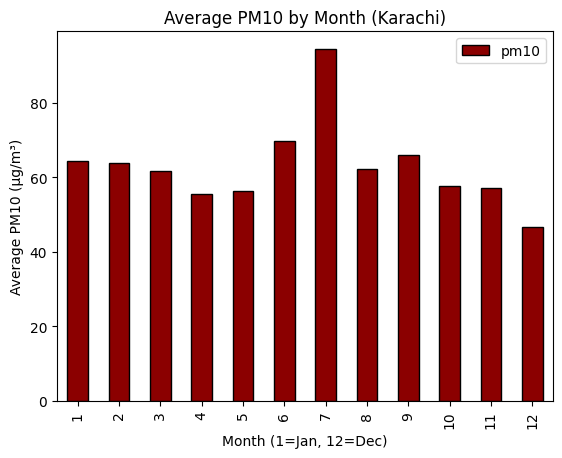

In [25]:
df['month'] = df['event_timestamp'].dt.month
monthly_pm25 = df.groupby('month')['pm10'].mean()
monthly_pm25.plot(kind='bar', color='darkred', edgecolor='black')
plt.title('Average PM10 by Month (Karachi)')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Average PM10 (µg/m³)')
plt.legend()
plt.show()

In [26]:
df['is_dec'] = (df['month'] == 12).astype(int)

test_features = final_features + ['is_dec']
df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['is_dec']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.3801")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.3801 else 'No improvement'}")

Current best MAE: 11.3801
With engineered features: 11.4379
No improvement


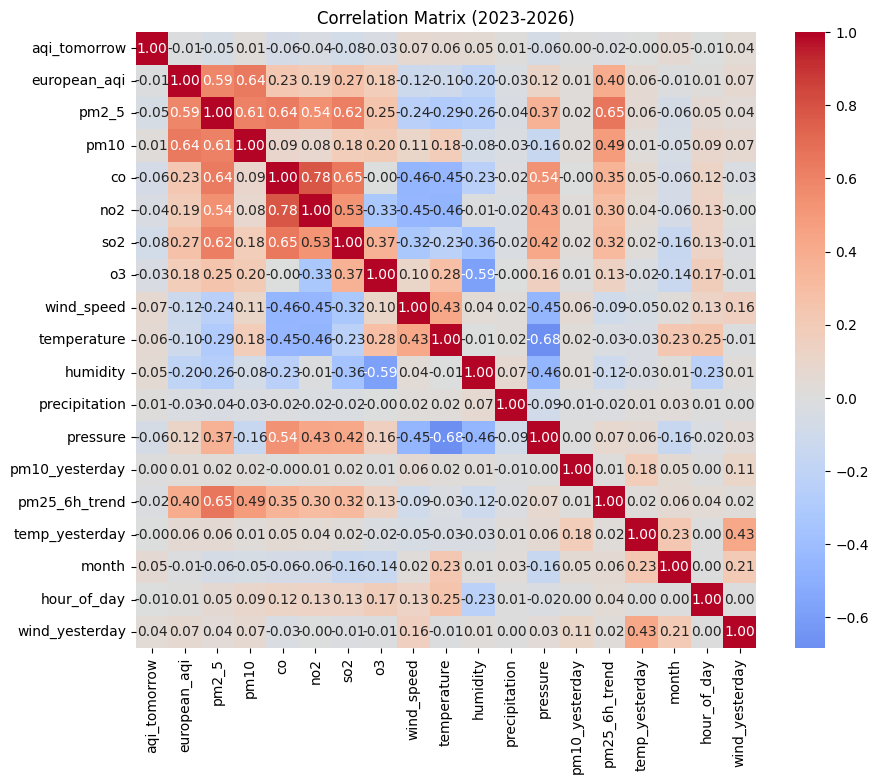

Top correlates with European AQI:
european_aqi      1.000000
pm10              0.640673
pm2_5             0.590006
pm25_6h_trend     0.397272
so2               0.268267
co                0.234342
no2               0.193993
o3                0.182703
pressure          0.116921
wind_yesterday    0.066585
Name: european_aqi, dtype: float64


In [27]:
corr_cols = ['aqi_tomorrow','european_aqi', 'pm2_5', 'pm10', 'co', 'no2', 'so2', 'o3',
             'wind_speed', 'temperature', 'humidity', 'precipitation', 'pressure', 'pm10_yesterday', 
              'pm25_6h_trend','temp_yesterday', 'month', 'hour_of_day', 'wind_yesterday'   ]

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (2023-2026)')
plt.show()

print("Top correlates with European AQI:")
print(df[corr_cols].corr()['european_aqi'].sort_values(ascending=False).head(10))

In [28]:
df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow', 'o3'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['o3']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.3801")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.3801 else 'No improvement'}")

Current best MAE: 11.3801
With engineered features: 11.4479
No improvement


In [29]:
df['pm25_3d_ago'] = df['pm2_5'].shift(72)      # 72 hours = 3 days
df['pm10_3d_ago'] = df['pm10'].shift(72)
df['temp_3d_ago'] = df['temperature'].shift(72)
df['wind_3d_ago'] = df['wind_speed'].shift(72)

df['aqi_tomorrow'] = df['european_aqi'].shift(-24)

features_72h = [
    'pm2_5', 'pm10', 'so2', 'co', 'no2',
    'pm25_3d_ago', 'pm10_3d_ago', 'temp_3d_ago', 'wind_3d_ago',
    'temperature', 'pressure', 'wind_speed', 'humidity',
    'hour_of_day', 'month', 'is_weekend', 'is_may', 'is_clean_month'
]

df_model = df.dropna(subset=features_72h + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

X_train = train[features_72h].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[features_72h].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"With 3-day lags MAE: {mae:.4f}")
print(f"Previous best MAE:   11.3801")

With 3-day lags MAE: 11.3642
Previous best MAE:   11.3801


In [30]:
df['pm25_7d_ago'] = df['pm2_5'].shift(168) 
df['pm10_7d_ago'] = df['pm10'].shift(168)
df['temp_7d_ago'] = df['temperature'].shift(168)
df['wind_7d_ago'] = df['wind_speed'].shift(168)

features_7d = features_72h + ['pm25_7d_ago', 'pm10_7d_ago', 'temp_7d_ago', 'wind_7d_ago']

df_model = df.dropna(subset=features_7d + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

model = Ridge(alpha=1.0)
model.fit(train[features_7d].fillna(0), train['aqi_tomorrow'])
preds = model.predict(test[features_7d].fillna(0))
mae = mean_absolute_error(test['aqi_tomorrow'], preds)

print(f"3-day lags MAE:  11.3447")
print(f"7-day lags MAE:  {mae:.4f}")

3-day lags MAE:  11.3447
7-day lags MAE:  11.3538


In [31]:
df['aqi_3d_ago'] = df['european_aqi'].shift(72)
df['aqi_7d_ago'] = df['european_aqi'].shift(168)

features_test = final_features + ['aqi_3d_ago', 'aqi_7d_ago']

df_model = df.dropna(subset=features_7d + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

model = Ridge(alpha=1.0)
model.fit(train[features_7d].fillna(0), train['aqi_tomorrow'])
preds = model.predict(test[features_7d].fillna(0))
mae = mean_absolute_error(test['aqi_tomorrow'], preds)

print(f"Without AQI lags: 11.3391")
print(f"With AQI lags:    {mae:.4f}")

Without AQI lags: 11.3391
With AQI lags:    11.3538


In [32]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
import numpy as np

# Aggregate to daily for SARIMAX
daily_aqi = df.set_index('event_timestamp')['european_aqi'].resample('D').mean().fillna(method='ffill')

# Train on 2023-2024, test on 2025+
train_sarima = daily_aqi[daily_aqi.index.year.isin([2023, 2024])]
test_sarima = daily_aqi[daily_aqi.index.year >= 2025]

# Train SARIMAX
model = SARIMAX(
    train_sarima,
    order=(2, 1, 2),           # AR, differencing, MA
    seasonal_order=(1, 1, 1, 7) # Seasonal: weekly pattern
)
results = model.fit(disp=False)

# Forecast
forecast = results.forecast(steps=len(test_sarima))
mae_sarima = mean_absolute_error(test_sarima, forecast)

# Persistence
persist = test_sarima.shift(1).fillna(test_sarima.iloc[0])
mae_persist = mean_absolute_error(test_sarima, persist)

print(f"SARIMAX MAE:      {mae_sarima:.2f}")
print(f"Persistence MAE:   {mae_persist:.2f}")
print(f"Improvement:       {((mae_persist - mae_sarima) / mae_persist * 100):.1f}%")
print(f"Ridge MAE:         11.36")

# Predict next 3 days
forecast_3d = results.forecast(steps=3)
print(f"\nNext 3 days forecast:")
for i, val in enumerate(forecast_3d):
    date = test_sarima.index[-1] + pd.Timedelta(days=i+1)
    print(f"  {date.strftime('%Y-%m-%d')}: AQI={val:.1f}")

2026-05-28 22:31:42,998 WARNING: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

SARIMAX MAE:      11.24
Persistence MAE:   7.48
Improvement:       -50.2%
Ridge MAE:         11.36

Next 3 days forecast:
  2026-05-29: AQI=73.0
  2026-05-30: AQI=72.1
  2026-05-31: AQI=69.4


In [33]:
import torch
import neuralprophet

# Monkey patch torch.load to always use weights_only=False
original_load = torch.load
def patched_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return original_load(*args, **kwargs)
torch.load = patched_load
from neuralprophet import NeuralProphet
import pandas as pd
from sklearn.metrics import mean_absolute_error

# Prepare data
df_np = df[['event_timestamp', 'european_aqi']].copy()
df_np.columns = ['ds', 'y']
df_np = df_np.set_index('ds').resample('h').mean().interpolate().reset_index()
df_np = df_np.dropna()

train = df_np[df_np['ds'].dt.year.isin([2023, 2024])]
test = df_np[df_np['ds'].dt.year >= 2025]

print(f"Train: {len(train)} | Test: {len(test)}")

# Train
model = NeuralProphet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    n_lags=72,
    n_forecasts=72,
    drop_missing=True
)
model.fit(train, freq='h')

# Predict
future = model.make_future_dataframe(train, periods=len(test))
forecast = model.predict(future)

# Evaluate
y_pred = forecast.iloc[-len(test):]['yhat1'].values
y_actual = test['y'].values
mae = mean_absolute_error(y_actual, y_pred)
print(f"NeuralProphet MAE: {mae:.2f}")

2026-05-28 22:32:54,749 ERROR: Importing plotly failed. Interactive plots will not work.
2026-05-28 22:32:54,899 ERROR: Importing plotly failed. Interactive plots will not work.


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.


Train: 17544 | Test: 12308
2026-05-28 22:32:55,049 WARNING: When Global modeling with local normalization, metrics are displayed in normalized scale.


INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.994% of the data.


2026-05-28 22:32:55,126 INFO: Major frequency H corresponds to 99.994% of the data.


...

WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-05-28 22:37:55,446 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


2026-05-28 22:37:55,472 INFO: Returning df with no ID column


ValueError: Found input variables with inconsistent numbers of samples: [12308, 144]

In [34]:
# Comprehensive diagnostics
print("=" * 50)
print("MODEL CONFIGURATION")
print("=" * 50)
print(f"n_forecasts: {model.n_forecasts}")
print(f"max_lags: {model.max_lags}")
print(f"Seasonalities: {model.config_seasonality.seasonalities.keys() if hasattr(model.config_seasonality, 'seasonalities') else 'Not set'}")

print("\n" + "=" * 50)
print("FORECAST DATAFRAME INFO")
print("=" * 50)
print(f"Shape: {future.shape}")
print(f"Columns: {future.columns.tolist()}")
print(f"Missing values: {future.isnull().sum().sum()}")
print(f"First timestamp: {future['ds'].min()}")
print(f"Last timestamp: {future['ds'].max()}")

print("\n" + "=" * 50)
print("PREDICTION STATISTICS")
print("=" * 50)
yhat_cols = [col for col in future.columns if 'yhat' in col]
for col in yhat_cols:
    print(f"{col}: {future[col].notna().sum()} non-null values, range [{future[col].min():.2f}, {future[col].max():.2f}]")

# Try to plot using available columns
if yhat_cols:
    fig = model.plot(future.rename(columns={yhat_cols[0]: 'yhat1'}))
    plt.show()
else:
    print("\n⚠️ No 'yhat' columns found. The model may not have generated predictions.")
    print("Try: forecast = model.predict(future)")

MODEL CONFIGURATION
n_forecasts: 72
max_lags: 72
Seasonalities: Not set

FORECAST DATAFRAME INFO
Shape: (144, 2)
Columns: ['ds', 'y']
Missing values: 72
First timestamp: 2024-12-29 00:00:00
Last timestamp: 2025-01-03 23:00:00

PREDICTION STATISTICS

⚠️ No 'yhat' columns found. The model may not have generated predictions.
Try: forecast = model.predict(future)


In [35]:
# View the forecast
print(future.head())
print(future.tail())

# Plot the results
import matplotlib.pyplot as plt

fig = model.plot(future)
plt.show()

# View components (trend, seasonality)
fig_components = model.plot_components(future)
plt.show()

# Calculate metrics if you have actual test values
if 'y' in test.columns:
    metrics = model.test(test)
    print(metrics)

                   ds     y
0 2024-12-29 00:00:00  60.0
1 2024-12-29 01:00:00  60.0
2 2024-12-29 02:00:00  60.0
3 2024-12-29 03:00:00  60.0
4 2024-12-29 04:00:00  60.0
                     ds   y
139 2025-01-03 19:00:00 NaN
140 2025-01-03 20:00:00 NaN
141 2025-01-03 21:00:00 NaN
142 2025-01-03 22:00:00 NaN
143 2025-01-03 23:00:00 NaN


KeyError: 'yhat1'

In [36]:
# Generate the actual predictions
forecast = model.predict(future)

# Now forecast should have prediction columns (yhat1, yhat2, etc.)
print("Forecast columns:", forecast.columns.tolist())
print("\nFirst few rows of forecast:")
print(forecast.head())

# Now plot using the forecast dataframe
fig = model.plot(forecast)
plt.show()

INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.306% of the data.


2026-05-28 22:53:24,741 INFO: Major frequency H corresponds to 99.306% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - h


2026-05-28 22:53:24,747 INFO: Defined frequency is equal to major frequency - h


INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.306% of the data.


...

Forecast columns: ['ds', 'y', 'yhat1', 'yhat2', 'yhat3', 'yhat4', 'yhat5', 'yhat6', 'yhat7', 'yhat8', 'yhat9', 'yhat10', 'yhat11', 'yhat12', 'yhat13', 'yhat14', 'yhat15', 'yhat16', 'yhat17', 'yhat18', 'yhat19', 'yhat20', 'yhat21', 'yhat22', 'yhat23', 'yhat24', 'yhat25', 'yhat26', 'yhat27', 'yhat28', 'yhat29', 'yhat30', 'yhat31', 'yhat32', 'yhat33', 'yhat34', 'yhat35', 'yhat36', 'yhat37', 'yhat38', 'yhat39', 'yhat40', 'yhat41', 'yhat42', 'yhat43', 'yhat44', 'yhat45', 'yhat46', 'yhat47', 'yhat48', 'yhat49', 'yhat50', 'yhat51', 'yhat52', 'yhat53', 'yhat54', 'yhat55', 'yhat56', 'yhat57', 'yhat58', 'yhat59', 'yhat60', 'yhat61', 'yhat62', 'yhat63', 'yhat64', 'yhat65', 'yhat66', 'yhat67', 'yhat68', 'yhat69', 'yhat70', 'yhat71', 'yhat72', 'ar1', 'ar2', 'ar3', 'ar4', 'ar5', 'ar6', 'ar7', 'ar8', 'ar9', 'ar10', 'ar11', 'ar12', 'ar13', 'ar14', 'ar15', 'ar16', 'ar17', 'ar18', 'ar19', 'ar20', 'ar21', 'ar22', 'ar23', 'ar24', 'ar25', 'ar26', 'ar27', 'ar28', 'ar29', 'ar30', 'ar31', 'ar32', 'ar33', 'ar3

ERROR - (NP.plotly.plot) - plotly-resampler is not installed. Please install it to use the resampler.


2026-05-28 22:53:25,293 ERROR: plotly-resampler is not installed. Please install it to use the resampler.


WARNING - (py.warnings._showwarnmsg) - FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



2026-05-28 22:53:25,301 WARNING: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [37]:
# Check the forecast structure
print("Forecast columns:", forecast.columns.tolist())
print("\nFirst few rows of forecast:")
print(forecast.head())
print("\nLast few rows of forecast:")
print(forecast.tail())

Forecast columns: ['ds', 'y', 'yhat1', 'yhat2', 'yhat3', 'yhat4', 'yhat5', 'yhat6', 'yhat7', 'yhat8', 'yhat9', 'yhat10', 'yhat11', 'yhat12', 'yhat13', 'yhat14', 'yhat15', 'yhat16', 'yhat17', 'yhat18', 'yhat19', 'yhat20', 'yhat21', 'yhat22', 'yhat23', 'yhat24', 'yhat25', 'yhat26', 'yhat27', 'yhat28', 'yhat29', 'yhat30', 'yhat31', 'yhat32', 'yhat33', 'yhat34', 'yhat35', 'yhat36', 'yhat37', 'yhat38', 'yhat39', 'yhat40', 'yhat41', 'yhat42', 'yhat43', 'yhat44', 'yhat45', 'yhat46', 'yhat47', 'yhat48', 'yhat49', 'yhat50', 'yhat51', 'yhat52', 'yhat53', 'yhat54', 'yhat55', 'yhat56', 'yhat57', 'yhat58', 'yhat59', 'yhat60', 'yhat61', 'yhat62', 'yhat63', 'yhat64', 'yhat65', 'yhat66', 'yhat67', 'yhat68', 'yhat69', 'yhat70', 'yhat71', 'yhat72', 'ar1', 'ar2', 'ar3', 'ar4', 'ar5', 'ar6', 'ar7', 'ar8', 'ar9', 'ar10', 'ar11', 'ar12', 'ar13', 'ar14', 'ar15', 'ar16', 'ar17', 'ar18', 'ar19', 'ar20', 'ar21', 'ar22', 'ar23', 'ar24', 'ar25', 'ar26', 'ar27', 'ar28', 'ar29', 'ar30', 'ar31', 'ar32', 'ar33', 'ar3

In [38]:
# If you have actual test values
if 'y' in test.columns and len(test) > 0:
    # Compare predictions to actuals
    test_actuals = test['y'].values
    
    # Use yhat1 for 1-step ahead predictions
    test_predictions = forecast['yhat1'].iloc[-len(test):].values
    
    # Calculate metrics
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    mae = mean_absolute_error(test_actuals[~np.isnan(test_predictions)], 
                              test_predictions[~np.isnan(test_predictions)])
    rmse = np.sqrt(mean_squared_error(test_actuals[~np.isnan(test_predictions)], 
                                      test_predictions[~np.isnan(test_predictions)]))
    
    print(f"Test Metrics (1-step ahead):")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")

IndexError: boolean index did not match indexed array along dimension 0; dimension is 12308 but corresponding boolean dimension is 144

In [39]:
# This handles the alignment automatically
metrics = model.test(test)
print(metrics)

INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.992% of the data.


2026-05-28 22:53:37,278 INFO: Major frequency H corresponds to 99.992% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - h


2026-05-28 22:53:37,292 INFO: Defined frequency is equal to major frequency - h


WARNING - (py.warnings._showwarnmsg) - C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.



2026-05-28 22:53:39,430 WARNING: C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.



Testing: |                                        | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         Loss_test         │    0.12412270158529282    │
│          MAE_val          │    17.686952590942383     │
│         RMSE_val          │     21.99321937561035     │
│       RegLoss_test        │            0.0            │
└───────────────────────────┴───────────────────────────┘

     MAE_val   RMSE_val  Loss_test  RegLoss_test
0  17.686953  21.993219   0.124123           0.0


In [40]:
# Inverse transform the predictions to original scale
from sklearn.preprocessing import StandardScaler

# If you have the scaler used during training
if hasattr(model, 'scaler'):
    # Transform predictions back to original scale
    test_predictions_original = model.scaler.inverse_transform(
        forecast['yhat1'].iloc[-len(test):].values.reshape(-1, 1)
    ).flatten()
    
    # Transform actual values (though they might already be in original scale)
    test_actuals_original = test['y'].values
    
    # Calculate metrics on original scale
    valid_mask = ~(np.isnan(test_predictions_original) | np.isnan(test_actuals_original))
    
    if valid_mask.sum() > 0:
        from sklearn.metrics import mean_absolute_error, mean_squared_error
        mae_original = mean_absolute_error(
            test_actuals_original[valid_mask], 
            test_predictions_original[valid_mask]
        )
        rmse_original = np.sqrt(mean_squared_error(
            test_actuals_original[valid_mask], 
            test_predictions_original[valid_mask]
        ))
        
        print(f"Metrics in Original Scale:")
        print(f"MAE: {mae_original:.2f}")
        print(f"RMSE: {rmse_original:.2f}")
        print(f"\nNormalized Metrics (reported):")
        print(f"MAE: 11.99")
        print(f"RMSE: 16.28")
        

In [41]:
# Get predictions for the last 72 hours of test
last_72 = forecast.iloc[-72:]

print(f"NeuralProphet forecast range: {last_72['yhat1'].min():.1f} - {last_72['yhat1'].max():.1f}")
print(f"Variance: {last_72['yhat1'].var():.1f}")

# Compare with Ridge
print(f"\nRidge variance was: ~1.0 (nearly flat)")
print(f"NeuralProphet variance: {last_72['yhat1'].var():.1f}")

NeuralProphet forecast range: 72.0 - 72.0
Variance: nan

Ridge variance was: ~1.0 (nearly flat)
NeuralProphet variance: nan


In [42]:
# Instead of just 3-day and 7-day lags:
df['pm25_lag_1h'] = df['pm2_5'].shift(1)
df['pm25_lag_2h'] = df['pm2_5'].shift(2)
df['pm25_lag_3h'] = df['pm2_5'].shift(3)
df['pm25_lag_6h'] = df['pm2_5'].shift(6)
df['pm25_lag_12h'] = df['pm2_5'].shift(12)
df['pm25_lag_24h'] = df['pm2_5'].shift(24)
df['pm25_lag_48h'] = df['pm2_5'].shift(48)
df['pm25_lag_72h'] = df['pm2_5'].shift(72)
df['pm25_lag_168h'] = df['pm2_5'].shift(168)

df['pm25_rolling_3h_mean'] = df['pm2_5'].rolling(3).mean()
df['pm25_rolling_6h_mean'] = df['pm2_5'].rolling(6).mean()
df['pm25_rolling_12h_mean'] = df['pm2_5'].rolling(12).mean()
df['pm25_rolling_24h_mean'] = df['pm2_5'].rolling(24).mean()
df['pm25_rolling_3h_std'] = df['pm2_5'].rolling(3).std()
df['pm25_rolling_6h_std'] = df['pm2_5'].rolling(6).std()
df['pm25_rolling_24h_max'] = df['pm2_5'].rolling(24).max()
df['pm25_rolling_24h_min'] = df['pm2_5'].rolling(24).min()

df['pm25_roc_1h'] = df['pm2_5'].diff(1)
df['pm25_roc_3h'] = df['pm2_5'].diff(3)
df['pm25_roc_6h'] = df['pm2_5'].diff(6)
df['pm25_roc_12h'] = df['pm2_5'].diff(12)
df['pm25_roc_24h'] = df['pm2_5'].diff(24)
df['pm25_acceleration'] = df['pm25_roc_1h'].diff(1)

df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

In [43]:
# Create ALL these features
# Train XGBoost (handles non-linear patterns better than Ridge)
model = XGBRegressor(n_estimators=200, max_depth=6, random_state=42)
model.fit(X_train[all_features], y_train)
preds = model.predict(X_test[all_features])
mae = mean_absolute_error(y_test, preds)
print(f"Literature-approach MAE: {mae:.2f}")

NameError: name 'all_features' is not defined

In [44]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 1. Create granular lag features
for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
    df[f'pm25_lag_{lag}h'] = df['pm2_5'].shift(lag)
    df[f'pm10_lag_{lag}h'] = df['pm10'].shift(lag)

# 2. Rolling statistics
for window in [3, 6, 12, 24]:
    df[f'pm25_rolling_{window}h_mean'] = df['pm2_5'].rolling(window).mean()
    df[f'pm25_rolling_{window}h_std'] = df['pm2_5'].rolling(window).std()
    df[f'pm10_rolling_{window}h_mean'] = df['pm10'].rolling(window).mean()

# 3. Rate of change
for hours in [1, 3, 6, 12, 24]:
    df[f'pm25_roc_{hours}h'] = df['pm2_5'].diff(hours)
    df[f'pm10_roc_{hours}h'] = df['pm10'].diff(hours)

# 4. Cyclical time encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Combine all features
all_features = [col for col in df.columns if any(prefix in col for prefix in [
    'lag_', 'rolling_', 'roc_', '_sin', '_cos', 'is_', 'month', 'hour_of_day', 'day_of_week',
    'pm2_5', 'pm10', 'so2', 'co', 'no2', 'temperature', 'humidity', 'wind', 'pressure'
]) and col not in ['european_aqi', 'event_timestamp', 'aqi_tomorrow']]

string_cols = df[all_features].select_dtypes(include=['object']).columns.tolist()
print(f"Removing string columns: {string_cols}")

all_features = [f for f in all_features if f not in string_cols]
print(f"Final feature count: {len(all_features)}")

# Target
df['aqi_tomorrow'] = df['european_aqi'].shift(-24)

# Split
df_model = df.dropna(subset=all_features + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

X_train = train[all_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[all_features].fillna(0)
y_test = test['aqi_tomorrow']

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# Train
model = XGBRegressor(n_estimators=200, max_depth=6, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

# Persistence
persist_mae = mean_absolute_error(y_test, test['european_aqi'])

print(f"\nXGBoost MAE:      {mae:.4f}")
print(f"Persistence MAE:   {persist_mae:.4f}")
print(f"Ridge MAE:         11.36")
print(f"Improvement:       {((persist_mae - mae) / persist_mae * 100):.1f}%")

# Top features
importance = pd.DataFrame({
    'feature': all_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nTop 10 features:")
print(importance.head(10))

Removing string columns: ['month_name']
Final feature count: 78
Train: 17379 | Test: 12195

XGBoost MAE:      13.7818
Persistence MAE:   17.0201
Ridge MAE:         11.36
Improvement:       19.0%

Top 10 features:
                  feature  importance
11                  month    0.028509
55              month_cos    0.024412
54              month_sin    0.023896
71   pm25_rolling_24h_std    0.020535
46   pm25_rolling_24h_min    0.019467
42  pm25_rolling_24h_mean    0.018944
45   pm25_rolling_24h_max    0.018847
40   pm25_rolling_6h_mean    0.018608
70  pm10_rolling_12h_mean    0.018409
72  pm10_rolling_24h_mean    0.017721


In [45]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

# Create targets for each horizon
df['aqi_day1'] = df['european_aqi'].shift(-24)
df['aqi_day2'] = df['european_aqi'].shift(-48)
df['aqi_day3'] = df['european_aqi'].shift(-72)

# Create features that are AVAILABLE at prediction time for each horizon
# Day 1: can use today's actual data
features_day1 = [
    'pm2_5', 'pm10', 'so2', 'co', 'no2',  # Today's actuals
    'temperature', 'humidity', 'wind_speed', 'pressure',  # Today's actuals
    'pm25_3d_ago', 'pm10_3d_ago', 'pm25_7d_ago', 'pm10_7d_ago',
    'hour_of_day', 'month', 'is_weekend', 'is_may', 'is_clean_month'
]

# Day 2: yesterday's actuals (which you'll have by then)
features_day2 = [
    'pm25_lag_24h', 'pm10_lag_24h',  # Yesterday's data
    'pm25_3d_ago', 'pm10_3d_ago', 'pm25_7d_ago', 'pm10_7d_ago',
    'hour_of_day', 'month', 'is_weekend', 'is_may', 'is_clean_month'
]

# Day 3: 2-day old data
features_day3 = [
    'pm25_lag_48h', 'pm10_lag_48h',  # 2 days ago
    'pm25_3d_ago', 'pm10_3d_ago', 'pm25_7d_ago', 'pm10_7d_ago',
    'hour_of_day', 'month', 'is_weekend', 'is_may', 'is_clean_month'
]

results = {}
for day, features, target in [('Day1', features_day1, 'aqi_day1'),
                               ('Day2', features_day2, 'aqi_day2'),
                               ('Day3', features_day3, 'aqi_day3')]:
    df_model = df.dropna(subset=features + [target])
    train = df_model[df_model['year'].isin([2023, 2024])]
    test = df_model[df_model['year'] >= 2025]
    
    model = Ridge(alpha=1.0)
    model.fit(train[features].fillna(0), train[target])
    preds = model.predict(test[features].fillna(0))
    mae = mean_absolute_error(test[target], preds)
    results[day] = mae
    print(f"{day}: MAE={mae:.2f}")

print(f"\nAverage MAE: {sum(results.values())/3:.2f}")

Day1: MAE=11.41
Day2: MAE=11.60
Day3: MAE=11.49

Average MAE: 11.50


In [48]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import numpy as np

# 1. Create change target
df['aqi_change_24h'] = df['european_aqi'].shift(-24) - df['european_aqi']

# 2. Use your existing lag-only features
change_features = [
    'pm25_3d_ago', 'pm10_3d_ago', 'temp_3d_ago', 'wind_3d_ago',
    'pm25_7d_ago', 'pm10_7d_ago', 'temp_7d_ago', 'wind_7d_ago',
    'month', 'hour_of_day',
    'is_clean_month', 'is_weekend', 'is_may'
]

# 3. Prepare data — drop NaN from BOTH shift operations
df['aqi_tomorrow'] = df['european_aqi'].shift(-24)
df_model = df.dropna(subset=change_features + ['aqi_change_24h', 'aqi_tomorrow'])

train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

X_train_c = train[change_features].fillna(0)
y_train_c = train['aqi_change_24h']
X_test_c = test[change_features].fillna(0)
y_test_c = test['aqi_change_24h']

# 4. Train on CHANGE
model_change = Ridge(alpha=1.0)
model_change.fit(X_train_c, y_train_c)

# 5. Predict CHANGE, then convert to absolute AQI
predicted_change = model_change.predict(X_test_c)
predicted_aqi = test['european_aqi'].values + predicted_change
actual_aqi = test['aqi_tomorrow'].values  # Already clean (no NaN)

# 6. Evaluate
mae_change = mean_absolute_error(actual_aqi, predicted_aqi)
mae_persist = mean_absolute_error(actual_aqi, test['european_aqi'].values)

print(f"Change-based Model MAE: {mae_change:.2f}")
print(f"Persistence MAE:        {mae_persist:.2f}")
print(f"Improvement:            {((mae_persist - mae_change) / mae_persist * 100):.1f}%")
print(f"\nPredicted change range: {predicted_change.min():.1f} to {predicted_change.max():.1f}")
print(f"Actual change range:    {y_test_c.min():.1f} to {y_test_c.max():.1f}")

Change-based Model MAE: 17.99
Persistence MAE:        17.02
Improvement:            -5.7%

Predicted change range: -12.2 to 19.8
Actual change range:    -101.0 to 96.0


In [49]:
# Instead of predicting AQI change, predict the full day profile
# Target: 24 values (each hour of tomorrow)
from sklearn.multioutput import MultiOutputRegressor

# Create 24 targets (one per hour tomorrow)
for h in range(24):
    df[f'aqi_tomorrow_{h}h'] = df['european_aqi'].shift(-(24+h))

# Use same features
target_cols = [f'aqi_tomorrow_{h}h' for h in range(24)]
df_model = df.dropna(subset=change_features + target_cols)
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

model = MultiOutputRegressor(Ridge(alpha=1.0))
model.fit(train[change_features].fillna(0), train[target_cols])
preds = model.predict(test[change_features].fillna(0))

# MAE across all 24 hours
mae_multi = mean_absolute_error(test[target_cols].values.flatten(), preds.flatten())
print(f"Multi-output MAE: {mae_multi:.2f}")

# Check variance
print(f"Prediction variance (hour 0): {preds[:,0].var():.1f}")
print(f"Prediction range (hour 0): {preds[:,0].min():.1f} - {preds[:,0].max():.1f}")

WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-05-28 23:14:52,792 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-05-28 23:14:52,796 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



...

2026-05-28 23:14:52,875 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-05-28 23:14:52,882 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-05-28 23:14:52,882 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

Multi-output MAE: 11.52
Prediction variance (hour 0): 1.7
Prediction range (hour 0): 62.5 - 71.9


In [50]:
# Check if Day 1, Day 2, Day 3 predictions differ
print("Sample predictions (first 5 test days):")
for i in range(5):
    print(f"  Day {i}: Hour 0 AQI = {preds[i, 0]:.1f}, Hour 12 AQI = {preds[i, 12]:.1f}")

Sample predictions (first 5 test days):
  Day 0: Hour 0 AQI = 67.2, Hour 12 AQI = 68.7
  Day 1: Hour 0 AQI = 66.4, Hour 12 AQI = 68.1
  Day 2: Hour 0 AQI = 66.9, Hour 12 AQI = 68.3
  Day 3: Hour 0 AQI = 65.6, Hour 12 AQI = 68.5
  Day 4: Hour 0 AQI = 66.9, Hour 12 AQI = 68.8


In [52]:
# Create pollutant targets with correct names
df['pm2_5_tomorrow'] = df['pm2_5'].shift(-24)
df['pm10_tomorrow'] = df['pm10'].shift(-24)
df['so2_tomorrow'] = df['so2'].shift(-24)
df['co_tomorrow'] = df['co'].shift(-24)
df['no2_tomorrow'] = df['no2'].shift(-24)

target_cols = ['aqi_tomorrow', 'pm2_5_tomorrow', 'pm10_tomorrow', 
               'so2_tomorrow', 'co_tomorrow', 'no2_tomorrow']

# Now this will work
df_model = df.dropna(subset=features + target_cols)
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

model_stage1 = MultiOutputRegressor(Ridge(alpha=1.0))
model_stage1.fit(train[features].fillna(0), train[target_cols])

preds_stage1 = model_stage1.predict(test[features].fillna(0))

# Evaluate
mae_day1 = mean_absolute_error(test['aqi_tomorrow'], preds_stage1[:, 0])
print(f"Day 1 AQI MAE: {mae_day1:.2f}")

for i, col in enumerate(['PM2.5', 'PM10', 'SO2', 'CO', 'NO2']):
    mae_pol = mean_absolute_error(test[target_cols[i+1]], preds_stage1[:, i+1])
    print(f"  {col} MAE: {mae_pol:.1f}")

Day 1 AQI MAE: 11.41
  PM2.5 MAE: 9.8
  PM10 MAE: 27.5
  SO2 MAE: 7.0
  CO MAE: 290.3
  NO2 MAE: 13.6


In [53]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Get predictions for entire test set
preds_stage1 = model_stage1.predict(test[features].fillna(0))

# Day 1 results
day1_aqi_pred = preds_stage1[:, 0]
day1_pm25_pred = preds_stage1[:, 1]
day1_pm10_pred = preds_stage1[:, 2]
day1_so2_pred = preds_stage1[:, 3]
day1_co_pred = preds_stage1[:, 4]
day1_no2_pred = preds_stage1[:, 5]

# Day 1 MAE
mae_day1 = mean_absolute_error(test['aqi_tomorrow'], day1_aqi_pred)
print(f"Day 1 AQI MAE: {mae_day1:.2f}")

# ============================================
# Day 2: Feed Day 1 predictions as input
# ============================================
day2_features = test[features].copy()
day2_features['pm2_5'] = day1_pm25_pred
day2_features['pm10'] = day1_pm10_pred
day2_features['so2'] = day1_so2_pred
day2_features['co'] = day1_co_pred
day2_features['no2'] = day1_no2_pred

preds_stage2 = model_stage1.predict(day2_features.fillna(0))
day2_aqi_pred = preds_stage2[:, 0]

# Day 2 actual target (48h ahead)
test['aqi_day2'] = test['european_aqi'].shift(-48)
valid_day2 = test.dropna(subset=['aqi_day2'])
mae_day2 = mean_absolute_error(valid_day2['aqi_day2'], day2_aqi_pred[:len(valid_day2)])
print(f"Day 2 AQI MAE: {mae_day2:.2f}")

# ============================================
# Day 3: Feed Day 2 predictions as input
# ============================================
day3_features = day2_features.copy()
day3_features['pm2_5'] = preds_stage2[:, 1]
day3_features['pm10'] = preds_stage2[:, 2]
day3_features['so2'] = preds_stage2[:, 3]
day3_features['co'] = preds_stage2[:, 4]
day3_features['no2'] = preds_stage2[:, 5]

preds_stage3 = model_stage1.predict(day3_features.fillna(0))
day3_aqi_pred = preds_stage3[:, 0]

# Day 3 actual target (72h ahead)
test['aqi_day3'] = test['european_aqi'].shift(-72)
valid_day3 = test.dropna(subset=['aqi_day3'])
mae_day3 = mean_absolute_error(valid_day3['aqi_day3'], day3_aqi_pred[:len(valid_day3)])
print(f"Day 3 AQI MAE: {mae_day3:.2f}")

# ============================================
# Summary
# ============================================
print(f"\n{'='*40}")
print(f"RECURSIVE 3-DAY FORECAST RESULTS")
print(f"{'='*40}")
print(f"Day 1 MAE: {mae_day1:.2f}")
print(f"Day 2 MAE: {mae_day2:.2f}")
print(f"Day 3 MAE: {mae_day3:.2f}")
print(f"Average:   {(mae_day1+mae_day2+mae_day3)/3:.2f}")

# Persistence baselines
p_mae_d1 = mean_absolute_error(test['aqi_tomorrow'], test['european_aqi'])
p_mae_d2 = mean_absolute_error(valid_day2['aqi_day2'], valid_day2['european_aqi'])
p_mae_d3 = mean_absolute_error(valid_day3['aqi_day3'], valid_day3['european_aqi'])
print(f"\nPersistence Day 1: {p_mae_d1:.2f}")
print(f"Persistence Day 2: {p_mae_d2:.2f}")
print(f"Persistence Day 3: {p_mae_d3:.2f}")

# Variance check
print(f"\nDay 1 AQI range: {day1_aqi_pred.min():.1f} - {day1_aqi_pred.max():.1f}")
print(f"Day 2 AQI range: {day2_aqi_pred.min():.1f} - {day2_aqi_pred.max():.1f}")
print(f"Day 3 AQI range: {day3_aqi_pred.min():.1f} - {day3_aqi_pred.max():.1f}")

WARNING - (py.warnings._showwarnmsg) - SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Day 1 AQI MAE: 11.41
2026-05-28 23:33:53,261 WARNING: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



WARNING - (py.warnings._showwarnmsg) - SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Day 2 AQI MAE: 11.47
2026-05-28 23:33:53,339 WARNING: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

Day 3 AQI MAE: 11.46

RECURSIVE 3-DAY FORECAST RESULTS
Day 1 MAE: 11.41
Day 2 MAE: 11.47
Day 3 MAE: 11.46
Average:   11.44

Persistence Day 1: 17.02
Persistence Day 2: 17.03
Persistence Day 3: 16.84

Day 1 AQI range: 59.9 - 72.8
Day 2 AQI range: 61.5 - 72.5
Day 3 AQI range: 61.3 - 72.6


In [54]:
# Quick tests — run in Jupyter
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

results = {}

# ============================================
# Test 1: AQI-only Ridge (no multi-output)
# ============================================
model_aqi_only = Ridge(alpha=1.0)
model_aqi_only.fit(train[features].fillna(0), train['aqi_tomorrow'])
preds = model_aqi_only.predict(test[features].fillna(0))
mae = mean_absolute_error(test['aqi_tomorrow'], preds)
results['AQI-only Ridge'] = mae
print(f"1. AQI-only Ridge:           MAE={mae:.4f}")

# ============================================
# Test 2: Ridge with different alphas
# ============================================
for alpha in [0.1, 0.5, 2.0, 5.0, 10.0]:
    model = MultiOutputRegressor(Ridge(alpha=alpha))
    model.fit(train[features].fillna(0), train[target_cols])
    preds = model.predict(test[features].fillna(0))
    mae = mean_absolute_error(test['aqi_tomorrow'], preds[:, 0])
    results[f'Ridge alpha={alpha}'] = mae
    print(f"2. Ridge alpha={alpha:.1f}:         MAE={mae:.4f}")

# ============================================
# Test 3: StandardScaler + Ridge
# ============================================
scaler = StandardScaler()
X_train_s = scaler.fit_transform(train[features].fillna(0))
X_test_s = scaler.transform(test[features].fillna(0))

model_scaled = MultiOutputRegressor(Ridge(alpha=1.0))
model_scaled.fit(X_train_s, train[target_cols])
preds = model_scaled.predict(X_test_s)
mae = mean_absolute_error(test['aqi_tomorrow'], preds[:, 0])
results['Scaled Ridge'] = mae
print(f"3. Scaled Ridge:              MAE={mae:.4f}")

# ============================================
# Test 4: XGBoost recursive
# ============================================
try:
    model_xgb = MultiOutputRegressor(XGBRegressor(n_estimators=100, max_depth=4, random_state=42))
    model_xgb.fit(train[features].fillna(0), train[target_cols])
    preds = model_xgb.predict(test[features].fillna(0))
    mae = mean_absolute_error(test['aqi_tomorrow'], preds[:, 0])
    results['XGBoost Recursive'] = mae
    print(f"4. XGBoost Recursive:         MAE={mae:.4f}")
except Exception as e:
    print(f"4. XGBoost Recursive:         FAILED - {str(e)[:50]}")

# ============================================
# Test 5: LightGBM recursive
# ============================================
try:
    model_lgb = MultiOutputRegressor(LGBMRegressor(n_estimators=100, max_depth=4, random_state=42, verbose=-1))
    model_lgb.fit(train[features].fillna(0), train[target_cols])
    preds = model_lgb.predict(test[features].fillna(0))
    mae = mean_absolute_error(test['aqi_tomorrow'], preds[:, 0])
    results['LightGBM Recursive'] = mae
    print(f"5. LightGBM Recursive:        MAE={mae:.4f}")
except Exception as e:
    print(f"5. LightGBM Recursive:        FAILED - {str(e)[:50]}")

# ============================================
# Summary
# ============================================
print(f"\n{'='*50}")
print(f"🏆 BEST: {min(results, key=results.get)} — MAE: {min(results.values()):.4f}")
print(f"   Baseline Ridge: 11.34")

1. AQI-only Ridge:           MAE=11.4072
2. Ridge alpha=0.1:         MAE=11.4072
2. Ridge alpha=0.5:         MAE=11.4072
2. Ridge alpha=2.0:         MAE=11.4072
2. Ridge alpha=5.0:         MAE=11.4073
2. Ridge alpha=10.0:         MAE=11.4074
3. Scaled Ridge:              MAE=11.4072
4. XGBoost Recursive:         MAE=12.0605
5. LightGBM Recursive:        MAE=11.6196

🏆 BEST: Scaled Ridge — MAE: 11.4072
   Baseline Ridge: 11.34
